# Feature Engineering & RFM Analysis

**Objective:**
Transform the cleaned transaction-level data into customer-level behavioral features. We will primarily use the RFM (Recency, Frequency, Monetary) framework, evaluate additional features, analyze correlations, and prepare the final dataset for clustering.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_theme(style="whitegrid")

## 1. Load Cleaned Data

In [2]:
df = pd.read_csv('../data/processed/cleaned_online_retail.csv')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print(f"Loaded {df.shape[0]} cleaned transactions.")

Loaded 392692 cleaned transactions.


## 2. RFM Calculation Logic
* **Reference Date**: The day after the last transaction in the dataset (to ensure the minimum recency is 1 day).
* **Recency**: Days between the reference date and the customer's last purchase.
* **Frequency**: Number of unique invoices per customer.
* **Monetary**: Total revenue generated by the customer.
* **Treatment of Returns**: We already filtered out returns/cancellations in Phase 4, so these metrics represent successful purchases only.

In [3]:
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Reference Date for Recency: {reference_date}")

# Aggregate at customer level
customer_features = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('Revenue', 'sum'),
    TotalQuantity=('Quantity', 'sum'),
    UniqueProducts=('StockCode', 'nunique')
).reset_index()

# Calculate Average Order Value
customer_features['AverageOrderValue'] = customer_features['Monetary'] / customer_features['Frequency']

print(f"Extracted features for {customer_features.shape[0]} customers.")
customer_features.head()

Reference Date for Recency: 2011-12-10 12:50:00


Extracted features for 4338 customers.


,CustomerID,Recency,Frequency,Monetary,TotalQuantity,UniqueProducts,AverageOrderValue
0,12346.0,326,1,77183.60,74215,1,77183.600000
1,12347.0,2,7,4310.00,2458,103,615.714286
2,12348.0,75,4,1797.24,2341,22,449.310000
3,12349.0,19,1,1757.55,631,73,1757.550000
4,12350.0,310,1,334.40,197,17,334.400000


## 3. Feature Selection & Correlation Analysis
We need to assess relevance and redundancy. Highly correlated features can distort distance-based clustering algorithms.

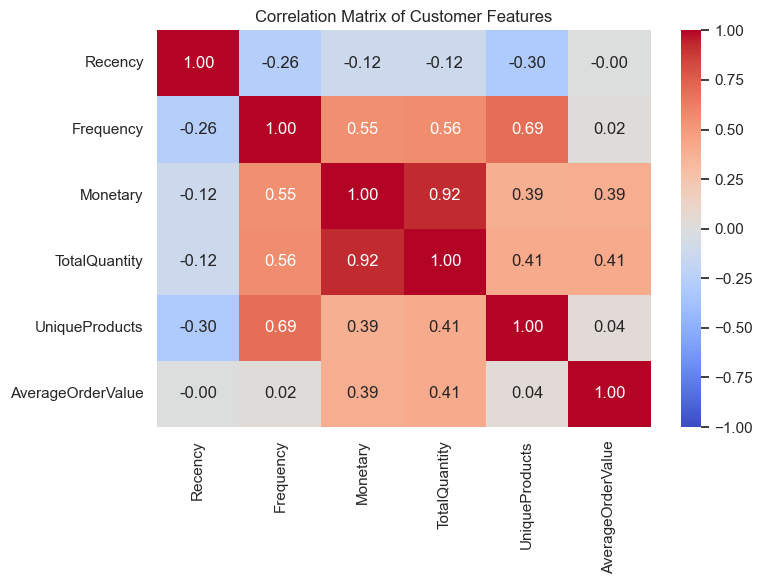

In [4]:
corr_matrix = customer_features.drop('CustomerID', axis=1).corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation Matrix of Customer Features")
plt.tight_layout()

# Save figure to the reports directory
plt.savefig('../reports/figures/correlation_matrix.png', dpi=300)
plt.show()

### Decisions on Feature Selection:
1. **Monetary vs TotalQuantity**: These are usually highly correlated. We will keep `Monetary` as it directly translates to business value.
2. **UniqueProducts vs Frequency**: These might show high correlation. `Frequency` is standard in RFM, so we prioritize it.
3. **AverageOrderValue**: This is mathematically derived from Monetary and Frequency (`Monetary / Frequency`), causing multicollinearity. We will drop it to keep the model simple, or keep it instead of Monetary if we want to separate volume from frequency. Standard RFM uses Monetary, so we will stick to the core RFM features to minimize redundancy.

In [5]:
final_features = customer_features[['CustomerID', 'Recency', 'Frequency', 'Monetary']]
print("Final Features selected for clustering:", final_features.columns.tolist())

Final Features selected for clustering: ['CustomerID', 'Recency', 'Frequency', 'Monetary']


## 4. Distributions and Scaling Preview
Let's look at the distribution of the final RFM features to anticipate our scaling strategy for Phase 6.

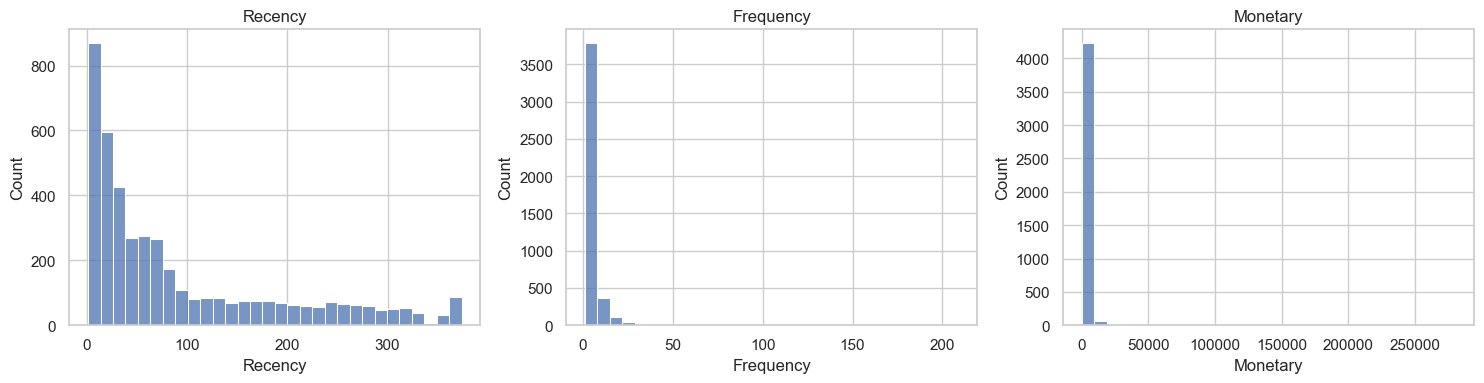

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(final_features['Recency'], bins=30, ax=axes[0]).set_title('Recency')
sns.histplot(final_features['Frequency'], bins=30, ax=axes[1]).set_title('Frequency')
sns.histplot(final_features['Monetary'], bins=30, ax=axes[2]).set_title('Monetary')
plt.tight_layout()
plt.savefig('../reports/figures/rfm_distributions_unscaled.png', dpi=300)
plt.show()

**Observation**: Frequency and Monetary are heavily right-skewed. We will definitely need log transformation and standardization before clustering.

In [7]:
final_features.to_csv('../data/processed/rfm_features.csv', index=False)
print("RFM dataset saved successfully to 'data/processed/rfm_features.csv'.")

RFM dataset saved successfully to 'data/processed/rfm_features.csv'.
